In [1]:
using PyPlot
using JLD2
using Statistics
using ProgressBars

In [2]:
function mask_ellipse(xc, yc, a, b, θ, width, height)
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

mask_ellipse (generic function with 1 method)

In [3]:
pathdir = "Y:/TwoDGas/2025/07/04"
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds
xc, yc, a, b, θ = 296, 362, 70, 40, 1.1; # Surround condensate for Y:/TwoDGas/2025/07/04
N_atoms_condensate = 80000;

### Check validity of condensate region

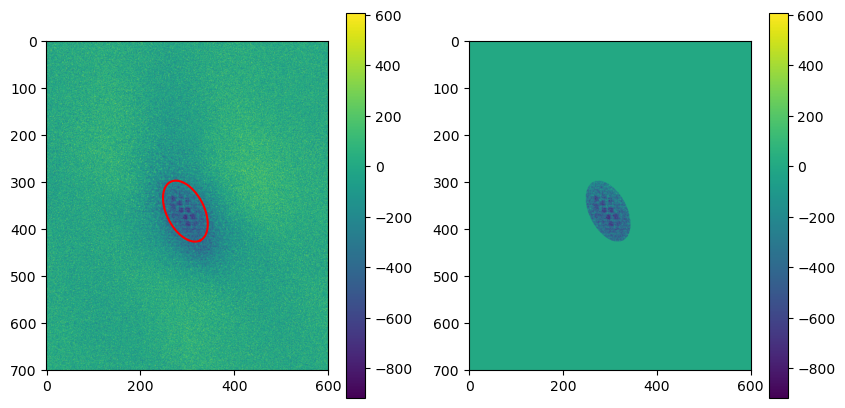

In [4]:
i, j = 1, 1
mask = mask_ellipse(xc, yc, a, b, θ, size(Imgs_atoms_crop_ds[i, j, :, :])[1], size(Imgs_atoms_crop_ds[i, j, :, :])[2])

close("all")
fig, axs = subplots(1, 2, figsize=(10, 5))

img1 = axs[1].imshow(Imgs_atoms_crop_ds[i, j, :, :]-Imgs_bkg_crop_ds[i, j, :, :])
colorbar(img1)

# Draw ellipse
θ_range = [0:0.01:2π;]
axs[1].plot((a*cos.(θ_range))*cos(θ).-(b*sin.(θ_range))*sin(θ).+xc, (a*cos.(θ_range))*sin(θ).+(b*sin.(θ_range))*cos(θ).+yc, color="r")

img2 = axs[2].imshow((Imgs_atoms_crop_ds[i, j, :, :].-Imgs_bkg_crop_ds[i, j, :, :]).*mask, vmin=minimum(Imgs_atoms_crop_ds[i, j, :, :]-Imgs_bkg_crop_ds[i, j, :, :]), vmax=maximum(Imgs_atoms_crop_ds[i, j, :, :]-Imgs_bkg_crop_ds[i, j, :, :]))
colorbar(img2)

# pygui(true); show()
pygui(false);

### Intensity integrated over the condensate

In [5]:
Iatoms_condensate, Ibkg_condensate, Idark_condensate = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

if length(τ_exp) == 1
    Convertion_factor = (0.85 * 0.107 * τ_exp)
end

for i = ProgressBar(1:length(Sat))
    if length(τ_exp) > 1
        Convertion_factor = (0.85 * 0.107 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        Iatoms_condensate[i, j] = sum(Imgs_atoms_crop_ds[i, j, :, :].*mask)
        Ibkg_condensate[i, j] = sum(Imgs_bkg_crop_ds[i, j, :, :].*mask)
        Idark_condensate[i, j] = sum(Imgs_dark_crop_ds[i, j, :, :].*mask)
        
        Iatoms_condensate[i, j] /= Convertion_factor
        Ibkg_condensate[i, j] /= Convertion_factor
        Idark_condensate[i, j] /= Convertion_factor
    end
end

Iatoms_condensate /= N_atoms_condensate
Ibkg_condensate /= N_atoms_condensate
Idark_condensate /= N_atoms_condensate;

0.0%┣                                               ┫ 0/6 [00:06<00:-37, -6s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:12<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [00:16<01:04, 16s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [00:20<00:30, 10s/it]
66.7%┣████████████████████████████████                ┫ 4/6 [00:24<00:16, 8s/it]
83.3%┣████████████████████████████████████████        ┫ 5/6 [00:28<00:07, 7s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:31<00:00, 6s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:31<00:00, 6s/it]


### Compute mean/std

In [6]:
Mean_atoms, Mean_bkg, Mean_dark = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))
Std_atoms, Std_bkg, Std_dark = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))

for i = 1:length(Sat)
    atoms, bkg, dark = [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            push!(atoms, Iatoms_condensate[i, j]), push!(bkg, Ibkg_condensate[i, j]), push!(dark, Idark_condensate[i, j])
        end
    end
    Mean_atoms[i], Mean_bkg[i], Mean_dark[i] = mean(atoms), mean(bkg), mean(dark)
    Std_atoms[i], Std_bkg[i], Std_dark[i] = std(atoms), std(bkg), std(dark)
end

## Plots

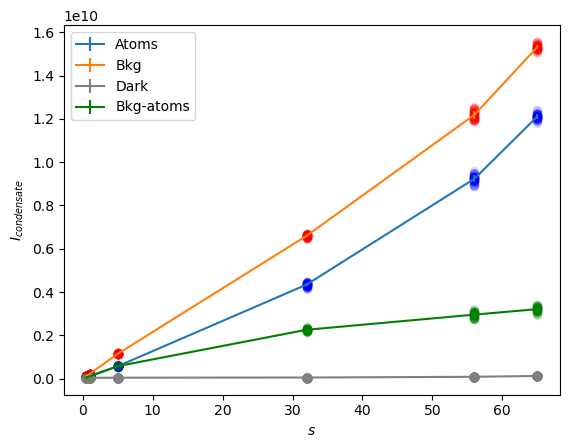

In [7]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Sat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Sat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")
errorbar(Sat, Mean_bkg-Mean_atoms, yerr=Std_dark, label="Bkg-atoms", color="g")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_condensate[i, j], color="b", alpha = 0.1)
        scatter(Sat[i], Ibkg_condensate[i, j], color="r", alpha = 0.1)
        scatter(Sat[i], Idark_condensate[i, j], color="grey")
        scatter(Sat[i], Ibkg_condensate[i, j]-Iatoms_condensate[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{condensate}")

legend()

# pygui(true); show();
pygui(false);

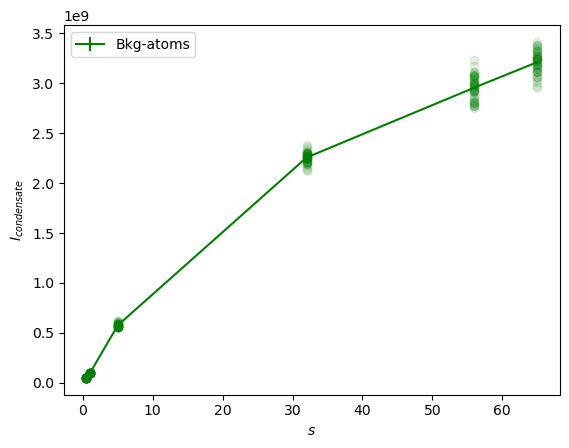

In [8]:
close("all")
fig = subplots()

errorbar(Sat, Mean_bkg-Mean_atoms, yerr=Std_dark, label="Bkg-atoms", color="g")

for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Ibkg_condensate[i, j]-Iatoms_condensate[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{condensate}")

legend()

# pygui(true); show();
pygui(false);

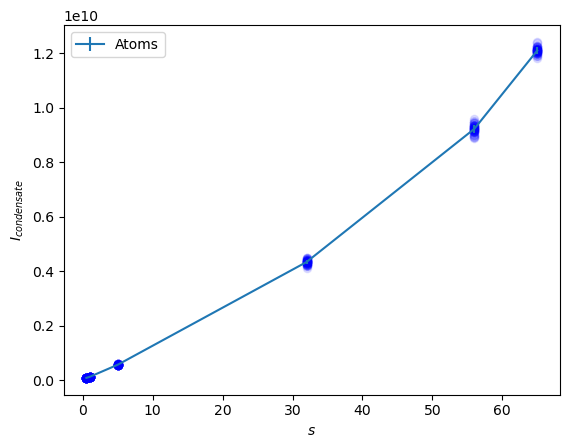

In [9]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_condensate[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{condensate}")

legend()

# pygui(true); show();
pygui(false);